# Regression lineaire : apprendre et predire le prix d'une maison

Objectif : comprendre les etapes de base du Machine Learning avec une seule variable, `GrLivArea` (surface habitable).

Nous ajouterons d'autres variables et des ameliorations seulement apres avoir compris cette version.


In [54]:
# numpy sert aux calculs numeriques.
import numpy as np

# pandas sert a lire et manipuler les tableaux de donnees.
import pandas as pd

# matplotlib sert a dessiner des graphiques.
import matplotlib.pyplot as plt

# Modele de regression lineaire.
from sklearn.linear_model import LinearRegression

# Outils pour mesurer l'erreur et separer les donnees.
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Outils de preparation des donnees.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cette valeur rend la separation des donnees reproductible.
RANDOM_STATE = 42


## 1. Charger les donnees

On lit les deux fichiers CSV : `train` contient les prix connus, `test` servira ensuite a faire des predictions.


In [55]:
# Le fichier train contient les exemples avec leur prix reel.
train = pd.read_csv('train.csv')

# Le fichier test contient les maisons pour lesquelles on veut predire le prix.
test = pd.read_csv('test.csv')

# shape donne le nombre de lignes et de colonnes.
print('Train :', train.shape)
print('Test  :', test.shape)

# head affiche les premieres lignes pour inspecter les donnees.
train.head()


Train : (1460, 81)
Test  : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [56]:
# On compte le nombre de colonnes numeriques et texte.
print('Types de colonnes :')
print(train.dtypes.value_counts())

# On cherche les colonnes qui contiennent des valeurs manquantes.
missing = train.isna().sum().sort_values(ascending=False)
print('\nColonnes avec des valeurs manquantes :')
print(missing[missing > 0].head(15))


Types de colonnes :
str        43
int64      35
float64     3
Name: count, dtype: int64

Colonnes avec des valeurs manquantes :
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
dtype: int64


## 2. Observer les donnees

Le jeu de donnees contient des variables numeriques et des variables texte. Certaines valeurs sont manquantes : nous allons les preparer avant l'entrainement.


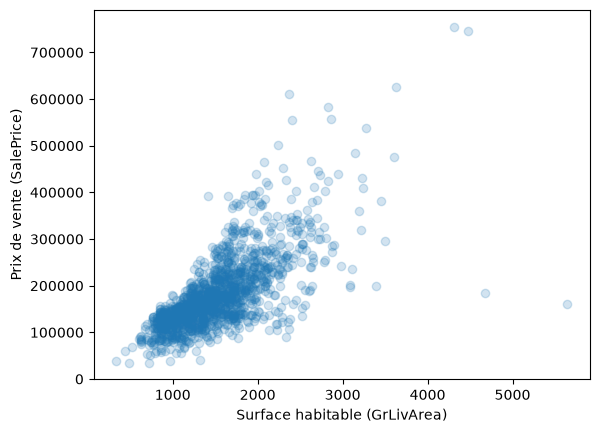

In [57]:
# Chaque point represente une maison.
# L'axe horizontal contient la surface et l'axe vertical le prix.
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.2)

# On donne un nom aux axes pour comprendre le graphique.
plt.xlabel('Surface habitable (GrLivArea)')
plt.ylabel('Prix de vente (SalePrice)')
plt.show()


In [58]:
# X contient toutes les variables qui peuvent expliquer le prix.
# On retire SalePrice car c'est la reponse, et Id car c'est seulement un identifiant.
X = train.drop(columns=['SalePrice', 'Id'])
y = train['SalePrice'].copy()

# X_test doit contenir exactement les memes variables que X.
X_test = test.drop(columns=['Id'])

# On separe les colonnes selon leur type.
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

# Preparation des variables numeriques :
# 1. remplacer les valeurs manquantes par la mediane ;
# 2. mettre les variables sur une echelle comparable.
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preparation des variables texte :
# 1. remplacer les valeurs manquantes par la categorie la plus frequente ;
# 2. transformer chaque categorie en colonnes 0/1.
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Le ColumnTransformer applique la bonne preparation a chaque type de colonne.
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

print('Nombre de variables numeriques :', len(numeric_features))
print('Nombre de variables texte     :', len(categorical_features))
print('Nombre total de variables     :', X.shape[1])

# Afficher les noms des colonnes categorielles.
print('\nColonnes categorielles :')
print(categorical_features)




Nombre de variables numeriques : 36
Nombre de variables texte     : 43
Nombre total de variables     : 79

Colonnes categorielles :
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


## 3. Choisir toutes les variables

`X` contient toutes les colonnes explicatives sauf `Id`. `y` contient le prix a predire (`SalePrice`).


## 4. Preparer, entrainer et evaluer

Les nombres sont completes puis standardises. Les variables texte sont completees puis transformees en colonnes 0/1. Ensuite, on separe les donnees et on evalue le modele.


In [59]:
# On separe les donnees :
# - 80 % pour apprendre
# - 20 % pour verifier le modele
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Le pipeline prepare les donnees puis entraine la regression lineaire.
# Le pretraitement est appris uniquement sur X_train pour eviter la fuite de donnees.
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Le modele apprend avec toutes les variables preparees.
model.fit(X_train, y_train)

# On predit les prix des maisons reservees pour la validation.
predictions = model.predict(X_valid)

# RMSE mesure l'ecart entre les vrais prix et les predictions.
# Plus le RMSE est petit, meilleur est le modele.
rmse = np.sqrt(mean_squared_error(y_valid, predictions))
print('RMSE avec toutes les variables :', round(rmse, 2))


RMSE avec toutes les variables : 29473.87


## 5. Faire les predictions finales

On entraine le pipeline complet sur toutes les maisons connues, puis on predit les prix du fichier `test.csv`.


In [60]:
# Maintenant que le modele a ete evalue, on le re-entraine
# avec toutes les donnees train disponibles.
model.fit(X, y)

# Le pipeline applique exactement la meme preparation a X_test.
test_predictions = model.predict(X_test)

# Un prix negatif n'a pas de sens, donc on le remplace par zero.
test_predictions = np.maximum(test_predictions, 0)

# On rassemble l'identifiant de la maison et sa prediction.
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_predictions
})

# On sauvegarde les predictions dans le fichier demande par Kaggle.
submission.to_csv('submission.csv', index=False)
submission.head()

# Le fichier test ne contient pas SalePrice : son RMSE sera calcule par Kaggle.


,Id,SalePrice
0,1461,113019.560700
1,1462,153912.768706
2,1463,187001.807939
3,1464,201034.988200
4,1465,202164.909226
